In [1]:
import math
import copy
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import random
from torch import onnx
import matplotlib.pyplot as plt


In [2]:
BOARD_SIZE = 5
K = 4  # four in a row


def has_four_in_a_row(board):
    # Rows
    for r in range(BOARD_SIZE):
        for c in range(BOARD_SIZE - K + 1):
            w = board[r, c:c+K]
            if abs(w.sum()) == K:
                return True

    # Columns
    for c in range(BOARD_SIZE):
        for r in range(BOARD_SIZE - K + 1):
            w = board[r:r+K, c]
            if abs(w.sum()) == K:
                return True

    # Diagonal \
    for r in range(BOARD_SIZE - K + 1):
        for c in range(BOARD_SIZE - K + 1):
            w = np.array([board[r+i, c+i] for i in range(K)])
            if abs(w.sum()) == K:
                return True

    # Diagonal /
    for r in range(BOARD_SIZE - K + 1):
        for c in range(K - 1, BOARD_SIZE):
            w = np.array([board[r+i, c-i] for i in range(K)])
            if abs(w.sum()) == K:
                return True

    return False

def action_to_index(row, col, symbol):
    sym = 0 if symbol == 1 else 1
    return row * 10 + col * 2 + sym

def index_to_action(idx):
    row = idx // 10
    col = (idx % 10) // 2
    symbol = 1 if idx % 2 == 0 else -1
    return row, col, symbol

def encode_state(board, current_player):
    x_plane = (board == 1).astype(np.float32)
    o_plane = (board == -1).astype(np.float32)
    empty_plane = (board == 0).astype(np.float32)
    turn_plane = np.ones_like(board, dtype=np.float32) \
        if current_player == 1 else np.zeros_like(board, dtype=np.float32)

    return np.stack([x_plane, o_plane, empty_plane, turn_plane], axis=0)



In [3]:
#test call

# Horizontal
b = np.zeros((5,5), dtype=int)
b[2, 0:4] = 1
assert has_four_in_a_row(b)

# Vertical
b = np.zeros((5,5), dtype=int)
b[0:4, 3] = -1
assert has_four_in_a_row(b)

# Diagonal \
b = np.zeros((5,5), dtype=int)
for i in range(4):
    b[i, i] = 1
assert has_four_in_a_row(b)

# Diagonal /
b = np.zeros((5,5), dtype=int)
for i in range(4):
    b[i, 4-i] = -1
assert has_four_in_a_row(b)

# Negative case
b = np.zeros((5,5), dtype=int)
b[0, 0:3] = 1
assert not has_four_in_a_row(b)

print("All tests passed")


All tests passed


In [11]:
class OrderChaosGame:
    def __init__(self):
        self.board = np.zeros((5, 5), dtype=np.int8)
        # self.player = 1  # Order starts

    def clone(self):
        g = OrderChaosGame()
        g.board = self.board.copy()
        return g

    def legal_actions(self):
        actions = []
        for r in range(5):
            for c in range(5):
                if self.board[r, c] == 0:
                    actions.append(action_to_index(r, c, 1))
                    actions.append(action_to_index(r, c, -1))
        return actions
    
    def get_current_player(self):
        if len(self.legal_actions())%2 == 0:
            return -1
        else:
            return 1

    def apply(self, action_idx):
        r, c, s = index_to_action(action_idx)
        assert self.board[r, c] == 0
        self.board[r, c] = s

    def terminal(self):
        if has_four_in_a_row(self.board):
            return True, 1  # Order wins when four in a row
        if np.all(self.board != 0):
            return True, -1  # Chaos wins on full board
        return False, 0

In [12]:
#unit tests for legal actions

g = OrderChaosGame()
assert set(g.legal_actions()) == set([action_to_index(r, c, s) for r in range(5) for c in range(5) for s in [1, -1]])

g.apply(action_to_index(0, 0, 1))
assert set(g.legal_actions()) == set([action_to_index(r, c, s) for r in range(5) for c in range(5) for s in [1, -1] if not (r == 0 and c == 0)])

g.apply(action_to_index(1, 1, -1))
assert set(g.legal_actions()) == set([action_to_index(r, c, s) for r in range(5) for c in range(5) for s in [1, -1] if not (r == 0 and c == 0) and not (r == 1 and c == 1)])

In [22]:
class MaxwellsDemonNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(4, 64, 3, padding=1)
        self.conv2 = nn.Conv2d(64, 64, 3, padding=1)

        # Policy head
        self.policy_conv = nn.Conv2d(64, 2, 1)
        self.policy_fc = nn.Linear(2 * 5 * 5, 50)

        # Value head
        self.value_conv = nn.Conv2d(64, 1, 1)
        self.value_fc1 = nn.Linear(25, 64)
        self.value_fc2 = nn.Linear(64, 1)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))

        p = F.relu(self.policy_conv(x))
        p = p.view(p.size(0), -1)
        p = F.softmax(self.policy_fc(p), dim=1)

        v = F.relu(self.value_conv(x))
        v = v.view(v.size(0), -1)
        v = F.relu(self.value_fc1(v))
        v = torch.tanh(self.value_fc2(v))

        return p, v


In [38]:
class MCTSNode:
    def __init__(self, prior, parent = None, game = OrderChaosGame(), action = None):
        self.P = prior          # prior probability
        self.parent = parent    # parent node reference
        self.visits = 0              # visit count
        self.wins = 0.0            # total value
        self.children = []      # action_idx -> MCTSNode
        self.game = game
        self.action = action
        self.untried_actions = self.game.legal_actions()  # to be initialized with legal actions when node is expanded
        
    @property
    def Q(self):
        return 0 if self.visits == 0 else self.wins / self.visits
    
    
    def is_fully_expanded(self):
        return len(self.untried_actions) == 0
    
    def expand(self):
        action = self.untried_actions.pop()
        game_copy = self.game.clone()
        game_copy.apply(action)
        child_node = MCTSNode(prior=0, parent=self, game=game_copy, action=action)  # Prior will be set by the neural network later
        self.children.append(child_node)
        return child_node
    
    def best_child(self, c_puct=1.0):
        for child in self.children:
            if child.visits == 0:
                return child
        
        def puct(child, c_puct=1.0):
            return child.Q + c_puct * child.P * math.sqrt(self.visits) / (1 + child.visits)
        
        return max(self.children, key=puct)
    
    def rollout(self, net: MaxwellsDemonNet):        

        game: OrderChaosGame = self.game.clone()
        device = next(net.parameters()).device

        while True:
            terminal, winner = game.terminal()
            if terminal:
                return winner
            
            state = torch.tensor(
                encode_state(game.board, game.get_current_player()),
                dtype=torch.float32
            ).unsqueeze(0).to(device)

            with torch.no_grad():
                policy, value = net(state)
                policy = policy.cpu().numpy()[0]
                value = value.item()
            
            legal_actions = game.legal_actions()
            legal_actions_mask = np.zeros_like(policy, dtype=bool)
            legal_actions_mask[legal_actions] = True
            policy[~legal_actions_mask] = 0
            policy_sum = policy.sum()
            if policy_sum > 0:
                policy /= policy_sum

            action_idx = np.argmax(policy)
            game.apply(action_idx)

    def backup(self, winner):
        self.visits += 1

        self.wins += 1 if winner == self.game.get_current_player() else -1

        if self.parent:
            self.parent.backup(winner)
    


In [39]:


def run_mcts(root_game: OrderChaosGame, net, simulations=100, c_puct=1.0):
    device = next(net.parameters()).device
    root = MCTSNode(prior=1.0, game=root_game)

    for _ in range(simulations):
        node = root

        while not node.game.terminal()[0] and node.is_fully_expanded():
            node = node.best_child()
        
        if not node.game.terminal()[0] and not node.is_fully_expanded():
            node = node.expand()
        
        winner = node.rollout(net=net)
        node.backup(winner=winner)
    
    pi = np.zeros(50, dtype=np.float32)
    for child in root.children:
        pi[child.action] = child.visits / root.visits
    
    pi_sum = pi.sum()
    if pi_sum > 0:
        pi /= pi_sum
        
    return pi


In [40]:
def sample_from_pi(pi, temperature=1.0):
    if temperature <= 1e-8:
        return int(np.argmax(pi))

    # Temperature scaling: lower temp -> greedier
    p = np.asarray(pi, dtype=np.float64) ** (1.0 / temperature)
    s = p.sum()
    if s <= 0:
        return int(np.argmax(pi))
    p /= s
    return int(np.random.choice(len(p), p=p))

def self_play_game(net, simulations=100, temp_moves=10, temp=1.0):
    game = OrderChaosGame()
    data = []
    move_count = 0

    while True:
        # Run MCTS from current position
        pi = run_mcts(game, net, simulations=simulations)

        # Store training example
        state = encode_state(game.board, game.get_current_player())
        data.append((state, pi, game.get_current_player()))

        # Choose move (argmax for now)
        # action = np.argmax(pi)
        if move_count < temp_moves:
            action = sample_from_pi(pi, temperature=temp)   # exploration early
        else:
            action = int(np.argmax(pi))                     # greedy later
        game.apply(action)
        move_count += 1

        terminal, winner = game.terminal()
        if terminal:
            break

    # Assign final outcomes
    final_data = []
    for state, pi, player in data:
        z = winner if player == 1 else -winner
        final_data.append((state, pi, z))

    return final_data

def az_loss(p_pred, v_pred, pi_target, z_target):
    value_loss = F.mse_loss(v_pred.squeeze(), z_target)
    policy_loss = -(pi_target * torch.log(p_pred + 1e-8)).sum(dim=1).mean()
    return value_loss + policy_loss

def train_step(net, optimizer, batch):
    states, pis, zs = zip(*batch)


    states = torch.from_numpy(np.array(states, dtype=np.float32))
    pis    = torch.from_numpy(np.array(pis, dtype=np.float32))
    zs     = torch.from_numpy(np.array(zs, dtype=np.float32))

    p_pred, v_pred = net(states)
    loss = az_loss(p_pred, v_pred, pis, zs)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    return loss.item()



In [ ]:
#Training loop

replay_buffer = []
NUM_ITERATIONS = 10
BATCH_SIZE = 128
MAX_BUFFER_SIZE = 35000
SELF_PLAY_GAMES = 100
SIMULATIONS_PER_MOVE = 400
NUM_GRADIENT_STEPS = 70
mean_loss_history = {}

net = MaxwellsDemonNet()
optimizer = torch.optim.Adam(net.parameters(), lr=1e-3)

for iteration in range(NUM_ITERATIONS):
    print(f"\n=== Iteration {iteration} ===")

    # --- Self-play ---
    net.eval()
    for g in range(SELF_PLAY_GAMES):
        game_data = self_play_game(net, simulations=SIMULATIONS_PER_MOVE)
        replay_buffer.extend(game_data)

    # Trim buffer
    if len(replay_buffer) > MAX_BUFFER_SIZE:
        replay_buffer = replay_buffer[-MAX_BUFFER_SIZE:]

    print(f"Replay buffer size: {len(replay_buffer)}")

    # --- Training ---
    net.train()
    losses = []

    for _ in range(NUM_GRADIENT_STEPS):  #gradient steps per iteration
        batch = random.sample(
            replay_buffer,
            min(BATCH_SIZE, len(replay_buffer))
        )
        loss = train_step(net, optimizer, batch)
        losses.append(loss)

    print(f"Mean loss: {sum(losses)/len(losses):.4f}")
    mean_loss_history[iteration + 1] = sum(losses)/len(losses)
    #checkpoint
    if (iteration + 1) % 10 == 0:  # save every 25 iterations
        torch.save(
            {
                "model_state_dict": net.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "iteration": iteration + 1,
                "replay_buffer": replay_buffer,
                "mean_loss_history": mean_loss_history,
            },
            "maxwells_demon_checkpoint.pt",
        )



=== Iteration 0 ===
Replay buffer size: 750
Mean loss: 3.5805

=== Iteration 1 ===
Replay buffer size: 1211
Mean loss: 2.0252

=== Iteration 2 ===
Replay buffer size: 1669
Mean loss: 1.5471

=== Iteration 3 ===
Replay buffer size: 2130
Mean loss: 1.3208

=== Iteration 4 ===
Replay buffer size: 2591
Mean loss: 1.2009

=== Iteration 5 ===
Replay buffer size: 3046
Mean loss: 1.1146

=== Iteration 6 ===
Replay buffer size: 3502
Mean loss: 1.0547

=== Iteration 7 ===
Replay buffer size: 3961
Mean loss: 1.0167

=== Iteration 8 ===
Replay buffer size: 4423
Mean loss: 1.0016

=== Iteration 9 ===
Replay buffer size: 4868
Mean loss: 0.9819


Text(0.5, 1.0, 'Training Loss')

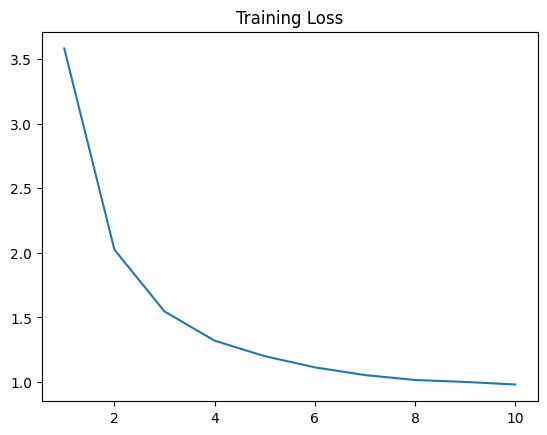

In [42]:
# checkpoint = torch.load("maxwells_demon_checkpoint.pt")

# net = MaxwellsDemonNet()

# net.load_state_dict(checkpoint["model_state_dict"])
# optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
# mean_loss_history = checkpoint["mean_loss_history"]
# current_iteration = checkpoint["iteration"]
# replay_buffer = checkpoint["replay_buffer"]


plt.plot(list(mean_loss_history.keys()), list(mean_loss_history.values()))
plt.title("Training Loss")

In [ ]:
# #retrain

# #Training loop

# NUM_ITERATIONS = 100
# BATCH_SIZE = 128
# MAX_BUFFER_SIZE = 35000
# SELF_PLAY_GAMES = 100
# SIMULATIONS_PER_MOVE = 400
# NUM_GRADIENT_STEPS = 70

# net = MaxwellsDemonNet()
# optimizer = torch.optim.Adam(net.parameters(), lr=1e-3)

# for iteration in range(current_iteration, current_iteration + NUM_ITERATIONS):
#     print(f"\n=== Iteration {iteration} ===")

#     # --- Self-play ---
#     net.eval()
#     for g in range(SELF_PLAY_GAMES):
#         game_data = self_play_game(net, simulations=SIMULATIONS_PER_MOVE)
#         replay_buffer.extend(game_data)

#     # Trim buffer
#     if len(replay_buffer) > MAX_BUFFER_SIZE:
#         replay_buffer = replay_buffer[-MAX_BUFFER_SIZE:]

#     print(f"Replay buffer size: {len(replay_buffer)}")

#     # --- Training ---
#     net.train()
#     losses = []

#     for _ in range(NUM_GRADIENT_STEPS):  #gradient steps per iteration
#         batch = random.sample(
#             replay_buffer,
#             min(BATCH_SIZE, len(replay_buffer))
#         )
#         loss = train_step(net, optimizer, batch)
#         losses.append(loss)

#     mean_loss_history[iteration + 1] = sum(losses)/len(losses)
#     print(f"Mean loss: {mean_loss_history[iteration + 1]:.4f}")
#     #checkpoint
#     if (iteration + 1) % 25 == 0:  # save every 25 iterations
#         print(f"Saving checkpoint at iteration {iteration + 1}...")
#         torch.save(
#             {
#                 "model_state_dict": net.state_dict(),
#                 "optimizer_state_dict": optimizer.state_dict(),
#                 "iteration": iteration + 1,
#                 "replay_buffer": replay_buffer,
#                 "mean_loss_history": mean_loss_history,
#             },
#             "maxwells_demon_checkpoint.pt",
#         )


In [43]:
#test model outputs for an array of inputs of different board states

net.eval()
test_states = [
    encode_state(np.zeros((5, 5), dtype=np.int8), 1),  # Empty board, Order's turn
    encode_state(np.array([[1, -1, 0, 0, 0],
                           [0, 1, -1, 0, 0],
                           [0, 0, 1, -1, 0],
                           [0, 0, 0, 0, 0],
                           [0, 0, 0, 0, 0]], dtype=np.int8), 1),  # Near win
    encode_state(np.array([[0, 1, 1, 1, 0],
                           [-1, -1, -1, 0, 0],
                           [0, 0, 0, 0, 0],
                           [0, 0, 0, 0, 0],
                           [0, 0, 0, 0, 0]], dtype=np.int8), -1),  # Near loss
    # near winning situation for chaos, there need to be an odd number of moves playes as well
    encode_state(np.array([[ 1, 1, 1, 0,-1],
                           [-1,-1, -1, 1, 0],
                           [ 0, 1,-1, -1, 0],
                           [ 0, 0, 1, 1, 0],
                           [ 0, -1, 0, 1, 0]], dtype=np.int8), -1)
]
for i, state in enumerate(test_states):
    state_tensor = torch.tensor(state, dtype=torch.float32).unsqueeze(0)
    with torch.no_grad():
        policy, value = net(state_tensor)
    print(f"Test State {i}:")
    print(f"best move: {index_to_action(np.argmax(policy.cpu()).item())}")
    print(f"Value: {value.item()}\n")

Test State 0:
best move: (4, 4, -1)
Value: -0.1783882975578308

Test State 1:
best move: (4, 4, -1)
Value: 0.9997367858886719

Test State 2:
best move: (4, 4, -1)
Value: 0.9999808073043823

Test State 3:
best move: (4, 4, -1)
Value: 0.9999938607215881



In [44]:
# Export to ONNX
net.eval()
net.cpu()

output_path = "../frontend/public/maxwells_demon.onnx"

dummy_input = torch.zeros(
    1, 4, 5, 5,
    dtype=torch.float32
)

torch.onnx.export(
    net,
    dummy_input,
    output_path,
    input_names=["board"],
    output_names=["policy", "value"],
    dynamic_axes={
        "board": {0: "batch"},
        "policy": {0: "batch"},
        "value": {0: "batch"}
    },
    opset_version=17
)

